In [ ]:
!nvidia-smi

Tue Feb 24 07:29:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   43C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch

torch.cuda.is_available()

True

Data Acquisition

In [ ]:
%%bash

wget https://raw.githubusercontent.com/inllclj/Project-1274287N/main/defect_cast.zip
wget https://raw.githubusercontent.com/inllclj/Project-1274287N/main/ok_cast.zip



In [ ]:
!ls -al

total 164260
drwxr-xr-x 6 root root      4096 Feb 24 07:30 .
drwxr-xr-x 1 root root      4096 Feb 24 07:23 ..
-rw-r--r-- 1 root root 136032048 Feb 23 17:56 best_casting_model.h5
drwxr-xr-x 5 root root      4096 Feb 23 08:07 data
drwxr-xr-x 4 root root      4096 Jan 28 05:23 dataset
-rw-r--r-- 1 root root  20078407 Feb 24 07:29 defect_cast.zip
drwxr-xr-x 2 root root      4096 Jan 27 15:22 .ipynb_checkpoints
-rw-r--r-- 1 root root  12065685 Feb 24 07:30 ok_cast.zip
drwxr-xr-x 3 root root      4096 Feb 23 16:32 SimpleCNN


Unzip images

In [ ]:
%%bash
unzip -o ok_cast.zip -d data
unzip -o defect_cast.zip -d data

## Data Understanding & Exploration (EDA)
### •	Inspect dataset structure and class labels (defective vs non-defective).
### •	Count images per class to identify class imbalance.
### •	Visually inspect sample images to understand:
##### -	Defect appearance
##### -	Lighting conditions
##### -	Background consistency
##### -	Image resolution and color format


Class Distribution:
-------------------
OK Images:  519
Defect Images: 781


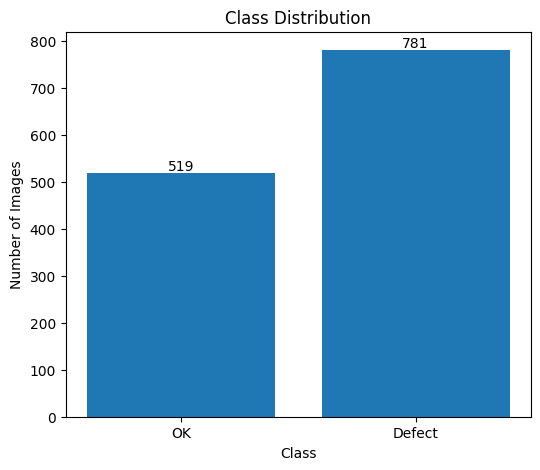

In [ ]:
# Class dstribution
import os
import matplotlib.pyplot as plt

# Paths
ok_dir = "data/ok_cast"
defect_dir = "data/defect_cast"

# Count images
ok_images = [f for f in os.listdir(ok_dir) if f.lower().endswith('.jpeg')]
defect_images = [f for f in os.listdir(defect_dir) if f.lower().endswith('.jpeg')]

ok_count = len(ok_images)
defect_count = len(defect_images)

print("Class Distribution:")
print("-------------------")
print(f"OK Images:  {ok_count}")
print(f"Defect Images: {defect_count}")

classes = ['OK', 'Defect']
counts = [ok_count, defect_count]

plt.figure(figsize=(6,5))
plt.bar(classes, counts)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

# Show values on bars
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

Defect Images size: (512, 512)
OK Images size:  (512, 512)


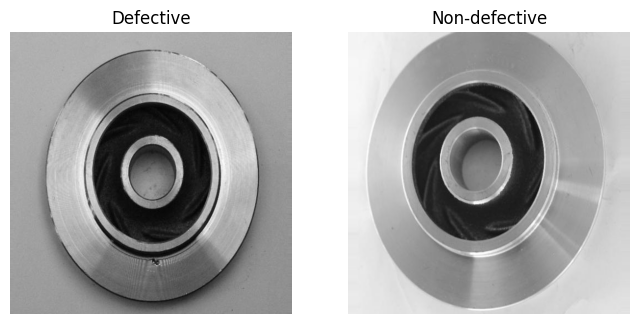

In [ ]:
# Visual inspection
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Defective image
random_defect_img = Image.open(os.path.join("data/defect_cast", random.choice(
    [f for f in os.listdir("data/defect_cast") if f.endswith('.jpeg')]
    )))
axes[0].imshow(random_defect_img)
axes[0].set_title("Defective")
print(f"Defect Images size: {random_defect_img.size}")
axes[0].axis("off")

# OK image
random_ok_img = Image.open(os.path.join("data/ok_cast", random.choice(
    [f for f in os.listdir("data/ok_cast") if f.endswith('.jpeg')]
    )))
axes[1].imshow(random_ok_img)
axes[1].set_title("Non-defective")
print(f"OK Images size:  {random_ok_img.size}")
axes[1].axis("off")

plt.show()


In [ ]:
# Data Cleaning, remove corrupted images
from PIL import Image
import os

def remove_corrupted_images(folder):
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        # Skip non-image files
        if not img_name.lower().endswith('.jpeg'):
            continue

        try:
            with Image.open(img_path) as img:
                img.verify()  # Check if image is corrupted
        except Exception:
            print(f"Removing corrupted image: {img_name}")
            os.remove(img_path)

base_dir = "data/defect_cast"
remove_corrupted_images(base_dir)

base_dir = "data/ok_cast"
remove_corrupted_images(base_dir)



In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

def split_data(src, train_dir, test_dir, split=0.8):
    """
    Clears target directories and splits images from src into train/test sets.
    """

    # 1. Clean up or create directories
    for directory in [train_dir, test_dir]:
        if os.path.exists(directory):
            print(f"Cleaning existing directory: {directory}")
            # Remove all files in the directory without deleting the folder itself
            shutil.rmtree(directory)

        os.makedirs(directory, exist_ok=True)

    # 2. Gather files
    # Lowercase check ensures we catch .JPEG, .jpg, and .jpeg
    all_images = [f for f in os.listdir(src)
                  if f.lower().endswith(('.jpeg', '.jpg'))]

    if not all_images:
        print(f"Warning: No images found in {src}")
        return

    # 3. Perform the split
    train_imgs, test_imgs = train_test_split(
        all_images,
        test_size=1 - split,
        random_state=42
    )

    # 4. Copy files to new locations
    print(f"Copying {len(train_imgs)} images to {train_dir}...")
    for img in train_imgs:
        shutil.copy(os.path.join(src, img), os.path.join(train_dir, img))

    print(f"Copying {len(test_imgs)} images to {test_dir}...")
    for img in test_imgs:
        shutil.copy(os.path.join(src, img), os.path.join(test_dir, img))

    print("Done!")

#### Preparing the data
#### Split the data into train and test by 80 to 20 proportion for ok images and def images

In [ ]:
# OK images
split_data(
    src="data/ok_cast",
    train_dir="dataset/train/ok",
    test_dir="dataset/test/ok",
    split=0.8
)

# Defective images
split_data(
    src="data/defect_cast",
    train_dir="dataset/train/faulty",
    test_dir="dataset/test/faulty",
    split=0.8
)

Copying 415 images to dataset/train/ok...
Copying 104 images to dataset/test/ok...
Done!
Copying 624 images to dataset/train/faulty...
Copying 157 images to dataset/test/faulty...
Done!


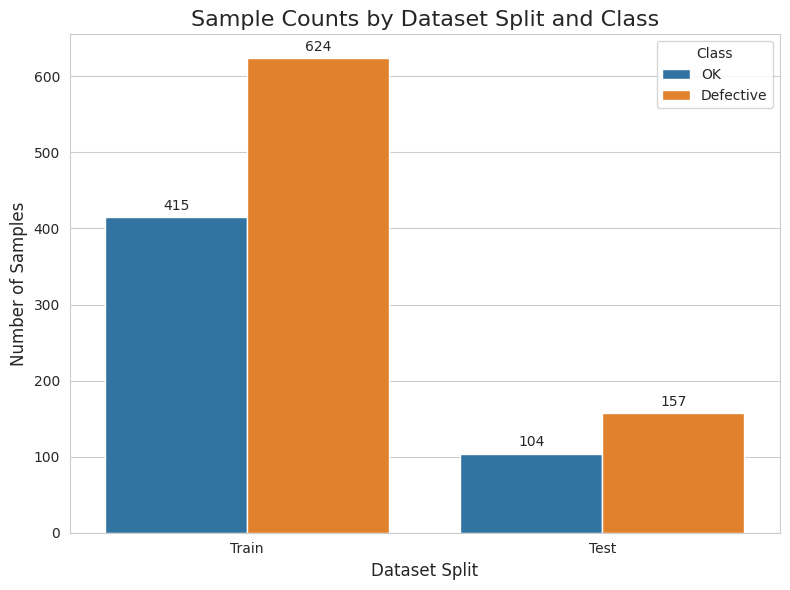

Train ratio (OK / Defective): 0.67
Test ratio (OK / Defective): 0.66


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Directory configuration
# -----------------------------
ROOT_DIR = "/content/dataset"
TRAIN_DIR = os.path.join(ROOT_DIR, "train")
TEST_DIR = os.path.join(ROOT_DIR, "test")

CLASS_NAMES = ["ok", "faulty"]

# -----------------------------
# Helper function
# -----------------------------
def count_images(base_dir, class_name):
    class_path = os.path.join(base_dir, class_name)
    if not os.path.exists(class_path):
        return 0
    return len([
        f for f in os.listdir(class_path)
        if f.lower().endswith(".jpeg")
    ])

# -----------------------------
# Count samples
# -----------------------------
train_ok = count_images(TRAIN_DIR, "ok")
train_defect = count_images(TRAIN_DIR, "faulty")
test_ok = count_images(TEST_DIR, "ok")
test_defect = count_images(TEST_DIR, "faulty")

# -----------------------------
# Create DataFrame
# -----------------------------
df = pd.DataFrame({
    "Split": ["Train", "Train", "Test", "Test"],
    "Class": ["OK", "Defective", "OK", "Defective"],
    "Count": [train_ok, train_defect, test_ok, test_defect]
})

# -----------------------------
# Visualization
# -----------------------------
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=df,
    x="Split",
    y="Count",
    hue="Class"
)

ax.set_title("Sample Counts by Dataset Split and Class", fontsize=16)
ax.set_xlabel("Dataset Split", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

# -----------------------------
# Class ratio reporting
# -----------------------------
if train_defect > 0:
    print(f"Train ratio (OK / Defective): {train_ok / train_defect:.2f}")
else:
    print("Train ratio: Defective class missing")

if test_defect > 0:
    print(f"Test ratio (OK / Defective): {test_ok / test_defect:.2f}")
else:
    print("Test ratio: Defective class missing")

The code counts the number of images in each class for training and testing datasets, stores the results in a DataFrame, visualizes the class distribution using a bar chart, and calculates the ratio between OK and defective samples to assess class balance.

This code helps to:

##### -Detect class imbalance
##### -Verify dataset split correctness
##### -Visualize distribution
##### -Avoid biased training

In [ ]:
!pip install mlflow

In [ ]:
import torch
import random
from glob import glob
from os.path import dirname, basename
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.io import read_image, ImageReadMode

device = "cuda" if torch.cuda.is_available() else "cpu"

class CastingDataset(Dataset):
    def __init__(self, folder_dir, transform=None):
        # 1. Collect all images from both subfolders
        self.fpaths = glob(f"{folder_dir}/faulty/*.jpeg") + glob(f"{folder_dir}/ok/*.jpeg")

        # 2. Shuffle once with a fixed seed for reproducibility
        random.seed(42)
        random.shuffle(self.fpaths)

        self.transform = transform

    def __len__(self):
        return len(self.fpaths)

    def __getitem__(self, idx):
        fpath = self.fpaths[idx]
        img = read_image(fpath, mode=ImageReadMode.GRAY).float() / 255.0

        if self.transform:
            img = self.transform(img)

    # Use "in" to check the path string directly
        if "ok" in fpath.lower():
            label = 0.0
        elif "faulty" in fpath.lower(): # matches 'defect' or 'defective'
            label = 1.0
        else:
        # If this happens, your glob found a file that isn't in a labeled folder
            raise ValueError(f"Could not determine label for: {fpath}")

        return img, torch.tensor([label])



In [ ]:
import torchvision.transforms as T

IM_SIZE = 224

# Training: Focus on variety to prevent overfitting
train_tfms = T.Compose([
    T.Resize((IM_SIZE, IM_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    T.RandomResizedCrop(IM_SIZE, scale=(0.9, 1.0)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.Normalize(mean=[0.5], std=[0.5]),
])

# Testing: Focus on consistency for accurate evaluation
test_tfms = T.Compose([
    T.Resize((IM_SIZE, IM_SIZE)),
    T.CenterCrop(IM_SIZE),
    T.Normalize(mean=[0.5], std=[0.5]),
])

Model, Loss Function, Optimizer

In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # 1. Feature Extraction (Convolutional Layers)
        self.features = nn.Sequential(
            self._conv_block(1, 16),   # Output: 16 x 112 x 112
            self._conv_block(16, 32),  # Output: 32 x 56 x 56
            self._conv_block(32, 64),  # Output: 64 x 28 x 28
        )

        # 2. Classifier (Fully Connected Layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

        self.loss_fn = nn.BCELoss()

    def _conv_block(self, ni, no):
        """Helper to create a standard Conv-ReLU-BatchNorm-Pool block"""
        return nn.Sequential(
            nn.Conv2d(ni, no, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(no),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


MLflow Setup

In [ ]:
import mlflow
import mlflow.pytorch

mlflow.end_run()
!pkill -f mlflow
# 1. Kill any existing MLflow processes
!pkill -f mlflow

# 2. Restart MLflow with specific flags for tunnels
import subprocess
import time

# We add '*' to allowed-hosts to accept any tunnel URL
# We add '*' to cors-origins to allow the browser to render the UI
cmd = [
    'mlflow', 'ui',
    '--port', '5000',
    '--host', '0.0.0.0',
    '--allowed-hosts', '*',
    '--cors-allowed-origins', '*'
]

subprocess.Popen(cmd)

# Give the server 10 seconds to fully load its database
print("MLflow server is starting with security bypass...")
time.sleep(10)

MLflow server is starting with security bypass...


In [ ]:
# Set the experiment name
mlflow.set_experiment("Casting_Defect_SimpleCNN")

<Experiment: artifact_location='/content/mlruns/1', creation_time=1771944911931, experiment_id='1', last_update_time=1771944911931, lifecycle_stage='active', name='Casting_Defect_SimpleCNN', tags={}, workspace='default'>

In [ ]:
import torch
from torchsummary import summary

# Set Hardware Accelerator
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize and Move Model
model = SimpleCNN().to(device)

# Display Blueprint
# use (1, 224, 224) because the model is built for Grayscale (1 channel)
summary(model, input_size=(1, IM_SIZE, IM_SIZE))

Using device: cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 224, 224]             160
              ReLU-2         [-1, 16, 224, 224]               0
       BatchNorm2d-3         [-1, 16, 224, 224]              32
         MaxPool2d-4         [-1, 16, 112, 112]               0
            Conv2d-5         [-1, 32, 112, 112]           4,640
              ReLU-6         [-1, 32, 112, 112]               0
       BatchNorm2d-7         [-1, 32, 112, 112]              64
         MaxPool2d-8           [-1, 32, 56, 56]               0
            Conv2d-9           [-1, 64, 56, 56]          18,496
             ReLU-10           [-1, 64, 56, 56]               0
      BatchNorm2d-11           [-1, 64, 56, 56]             128
        MaxPool2d-12           [-1, 64, 28, 28]               0
          Flatten-13                [-1, 50176]               0
           Linear-14

In [ ]:
train_ds = CastingDataset('dataset/train', transform=train_tfms)
test_ds  = CastingDataset('dataset/test',  transform=test_tfms)

# 2. Initialize DataLoaders
# Dataset returns tensors directly
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=32, shuffle=False) # No need to shuffle test data

# 3. Inspect a single batch
images, labels = next(iter(train_dl))

print(f"Images batch shape: {images.shape}") # Expected: [32, 1, 224, 224]
print(f"Labels batch shape: {labels.shape}") # Expected: [32, 1]

Images batch shape: torch.Size([32, 1, 224, 224])
Labels batch shape: torch.Size([32, 1])


Validation step for Training/Testing batch

In [ ]:
import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

# validation step for Training batch
def train_batch(images, labels, model, opt, loss_fn):
    model.train()
    preds = model(images)

    loss = loss_fn(preds, labels)
    acc = (preds > 0.5).float().eq(labels).float().mean()

    loss.backward()
    opt.step()
    opt.zero_grad()

    return loss.item(), acc.item()

# validation step for Testing batch
@torch.no_grad()
def validate_batch(images, labels, model, loss_fn):
    model.eval()
    preds = model(images)

    loss = loss_fn(preds, labels)
    acc = (preds > 0.5).float().eq(labels).float().mean()

    return loss.item(), acc.item()


Training Loop

In [ ]:
# del log
# best_accuracy = 0.0

In [ ]:
import os
import torch
from torch.optim import Adam
from torch_snippets import Report

# 1. Setup Models and directory
model = SimpleCNN().to(device)
optimizer = Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.BCELoss()  # This replaces model.criterion
n_epochs = 20

model_dir = "/content/SimpleCNN/models"
os.makedirs(model_dir, exist_ok=True)

# 2. Training Initialization
log = Report(n_epochs)
best_accuracy = 0.0

# # Safety check: end any previous runs that might be hanging
# mlflow.end_run()

# # Now start your experiment
# mlflow.set_experiment("Casting_Defect_SimpleCNN")

# --- Start the MLflow Run ---
# New Hyper-parameter tuning
with mlflow.start_run(run_name="FineTuned_SimpleCNN_v2"):
    # Log the strategy
    mlflow.log_params({
        "lr": 1e-4,
        "pos_weight": 3.0,
        "dropout": 0.3,
        "epochs": n_epochs,
        "batch_size": 32,
        "optimizer": "Adam",
        "im_size": 128
    })

# # --- Start the MLflow Run ---
# # Existing Hyper-parameter
# with mlflow.start_run(run_name="SimpleCNN_Standard"):

#     # Log Hyperparameters
#     mlflow.log_params({
#         "lr": 1e-3,
#         "epochs": n_epochs,
#         "batch_size": 32,
#         "optimizer": "Adam",
#         "im_size": IM_SIZE
#     })

    for ex in range(n_epochs):
        # --- TRAINING PHASE ---
        N = len(train_dl)
        for bx, (imgs, lbls) in enumerate(train_dl):
            imgs, lbls = imgs.to(device), lbls.to(device)
            loss, acc = train_batch(imgs, lbls, model, optimizer, loss_fn)
            log.record(ex + (bx + 1)/N, trn_loss=loss, trn_acc=acc, end='\r')

        # --- VALIDATION PHASE ---
        N = len(test_dl)
        epoch_val_accs = []
        epoch_val_losses = []  # <--- FIX 1: Define the missing list

        for bx, (imgs, lbls) in enumerate(test_dl):
            imgs, lbls = imgs.to(device), lbls.to(device)
            val_loss, val_acc = validate_batch(imgs, lbls, model, loss_fn)

            log.record(ex + (bx + 1)/N, val_loss=val_loss, val_acc=val_acc, end='\r')
            epoch_val_accs.append(val_acc)
            epoch_val_losses.append(val_loss)


        # Calculate Averages
        current_val_acc = sum(epoch_val_accs) / len(epoch_val_accs)
        current_val_loss = sum(epoch_val_losses) / len(epoch_val_losses)

        # Log to MLflow
        mlflow.log_metric("trn_loss", loss, step=ex)
        mlflow.log_metric("trn_acc", acc, step=ex)
        mlflow.log_metric("val_acc", current_val_acc, step=ex)
        mlflow.log_metric("val_loss", current_val_loss, step=ex)

        # Report Averages and Save
        log.report_avgs(ex + 1)

        if current_val_acc > best_accuracy:
            best_accuracy = current_val_acc
            save_path = f"{model_dir}/best_casting_model.pth"
            torch.save(model.state_dict(), save_path)
            print(f"New Best Model Saved! Manual Avg Val Acc: {current_val_acc:.4f}")

        torch.save(model.state_dict(), f"{model_dir}/model_epoch_{ex+1}.pth")


EPOCH: 1.000  val_loss: 0.669  trn_loss: 5.344  trn_acc: 0.697  val_acc: 0.738  (6.19s - 117.66s remaining)
New Best Model Saved! Manual Avg Val Acc: 0.7229
EPOCH: 2.000  val_loss: 0.499  trn_loss: 0.647  trn_acc: 0.703  val_acc: 0.768  (12.07s - 108.59s remaining)
New Best Model Saved! Manual Avg Val Acc: 0.7903
EPOCH: 3.000  val_loss: 0.419  trn_loss: 0.516  trn_acc: 0.724  val_acc: 0.808  (17.92s - 101.55s remaining)
New Best Model Saved! Manual Avg Val Acc: 0.8076
EPOCH: 4.000  val_loss: 0.430  trn_loss: 0.472  trn_acc: 0.738  val_acc: 0.815  (23.91s - 95.63s remaining)
New Best Model Saved! Manual Avg Val Acc: 0.8368
EPOCH: 5.000  val_loss: 0.435  trn_loss: 0.479  trn_acc: 0.739  val_acc: 0.833  (29.82s - 89.46s remaining)
EPOCH: 6.000  val_loss: 0.370  trn_loss: 0.476  trn_acc: 0.775  val_acc: 0.844  (35.65s - 83.17s remaining)
New Best Model Saved! Manual Avg Val Acc: 0.8438
EPOCH: 7.000  val_loss: 0.367  trn_loss: 0.431  trn_acc: 0.766  val_acc: 0.826  (41.54s - 77.15s remainin

In [ ]:
# # Check if you have both 0s and 1s in your batch
# imgs, lbls = next(iter(train_dl))
# print(f"Labels in this batch: {lbls.view(-1)}")
# # If you only see 0s or only 1s, your dataset loading logic is broken.

Labels in this batch: tensor[32] x∈[0., 1.000] μ=0.656 σ=0.483


Metrics & Confusion Matrix

100%|██████████| 121/121 [00:00<00:00, 6648.73it/s]


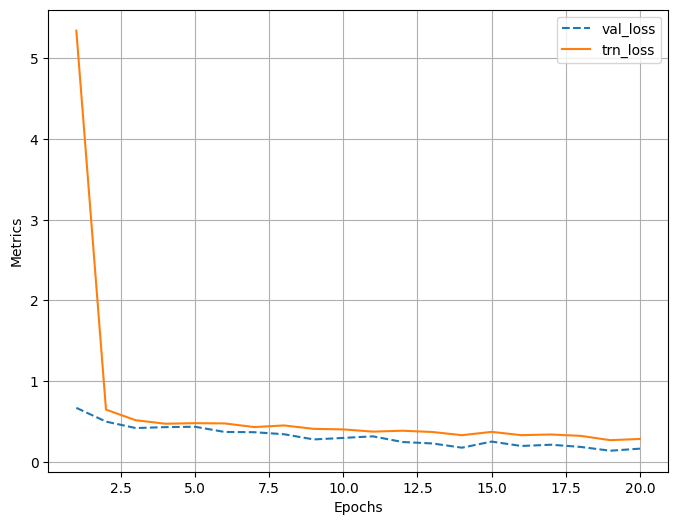

100%|██████████| 121/121 [00:00<00:00, 6400.61it/s]


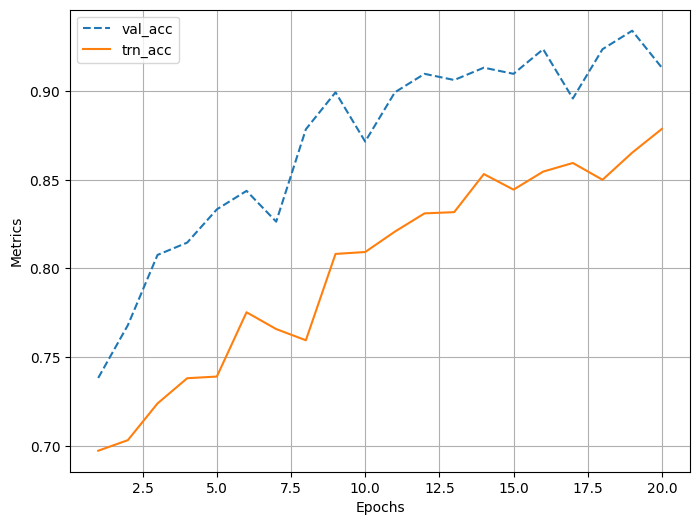

In [ ]:
log.plot_epochs(["val_loss", "trn_loss"])
log.plot_epochs(["val_acc", "trn_acc"])

#### In Epoch 19:
#### Train Accuracy : 0.865
#### Validation Accuracy : 0.934
#### Train Loss : 0.269
#### Validation Loss : 0.138
#### Save the best casting model to final modelto "/content/SimpleCNN/models/best_casting_model.pth"

In [ ]:
final_model = SimpleCNN().to(device)
# Add 'models/' to the path
final_model.load_state_dict(torch.load("/content/SimpleCNN/models/best_casting_model.pth", weights_only=True))
final_model.eval() # Save the best model

SimpleCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (classifier): Sequential(

### Predicting Batch

In [ ]:
@torch.no_grad()
def predict_batch(batch, model):
    model.eval()

    # 1. Unpack only two items (images and labels)
    images, labels = batch

    # 2. Move to device
    images = images.to(device)

    # 3. Get predictions from model
    preds = model(images)

    # 4. Convert probabilities to binary classes (0 or 1)
    # We use squeeze() to ensure [Batch, 1] becomes [Batch]
    preds_class = (preds.squeeze() > 0.5).long()

    # 5. Return everything on CPU for metrics/plotting
    # labels.squeeze() ensures the ground truth has the same shape as preds_class
    return preds_class.cpu(), labels.squeeze().cpu()

In [ ]:
all_preds = []
all_targets = []

for batch in test_dl:
    preds, targets = predict_batch(batch, final_model)
    all_preds.append(preds)
    all_targets.append(targets)

all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

print("Predictions:", all_preds.shape)
print("Targets:", all_targets.shape)

Predictions: torch.Size([261])
Targets: torch.Size([261])


[[102   2]
 [ 17 140]]


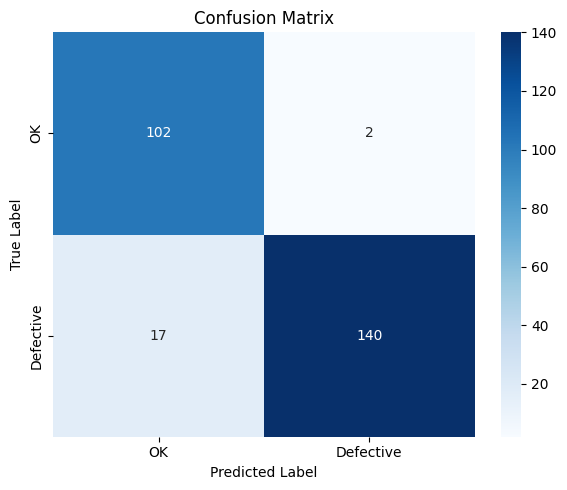

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_targets, all_preds)
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["OK", "Defective"],
    yticklabels=["OK", "Defective"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()

# --- Save BEFORE Show ---
plt.savefig("cm_plot.png")
mlflow.log_artifact("cm_plot.png") # Uploads the image to the UI

plt.show()

# Extract counts from Confusion Matrix
tn, fp, fn, tp = cm.ravel()
mlflow.log_metric("false_negatives", fn)
mlflow.log_metric("false_positives", fp)


f1, Precision and Recall Metrices

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import torch
import numpy as np

def get_metrics(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader: # Unpack 2 items only
            x, y = x.to(device), y.to(device)

            # 1. Get model output (already contains Sigmoid)
            outputs = model(x)

            # 2. Convert to binary classes
            # Squeeze ensures shape [32, 1] becomes [32]
            preds = (outputs.squeeze() > 0.5).int()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().squeeze().numpy())

    # 3. Calculate metrics
    # We use 'binary' average by default
    f1 = f1_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)

    return f1, precision, recall

# Ensure to use if SimpleCNN instance
f1, precision, recall = get_metrics(model, test_dl, device)

print(f"Metrics on Test Set:")
print(f"F1-Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")


# Log final calculation metrics
mlflow.log_metrics({
  "final_f1": f1,
  "final_precision": precision,
  "final_recall": recall
  })

# Save the final PyTorch model artifact
mlflow.pytorch.log_model(model, "simple_cnn_best_model")

# The 'with' block ends here

2026/02/24 18:05:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/24 18:05:56 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/02/24 18:05:56 WARNING mlflow.utils.requirements_utils: Found torch version (2.9.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.9.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Metrics on Test Set:
F1-Score:  0.9180
Precision: 0.9459
Recall:    0.8917


2026/02/24 18:06:01 WARNING mlflow.utils.requirements_utils: Found torch version (2.9.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.9.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


### MLFlow tunnel activation

In [ ]:
# 1. Kill any existing MLflow processes
!pkill -f mlflow

# 2. Restart MLflow with specific flags for tunnels
import subprocess
import time

# add '*' to allowed-hosts to accept any tunnel URL
# add '*' to cors-origins to allow the browser to render the UI
cmd = [
    'mlflow', 'ui',
    '--port', '5000',
    '--host', '0.0.0.0',
    '--allowed-hosts', '*',
    '--cors-allowed-origins', '*'
]

subprocess.Popen(cmd)

# Give the server 10 seconds to fully load its database
print("MLflow server is starting with security bypass...")
time.sleep(10)

MLflow server is starting with security bypass...


In [ ]:
import getpass
import os

# Start the MLflow UI in the background on port 5000
get_ipython().system_raw("mlflow ui --port 5000 &")

# Get your public IP (this acts as the password for the localtunnel)
print("Your Tunnel Password (IP) is:")
!curl ipv4.icanhazip.com
# 1. Get your IP for the tunnel password
ip = !curl -s ipv4.icanhazip.com
print(f"Tunnel Password / Endpoint IP: {ip[0]}")

# 2. Start the tunnel
# We keep the local-host fix just in case
!npx localtunnel --port 5000 --local-host 127.0.0.1

Your Tunnel Password (IP) is:
35.247.179.234
Tunnel Password / Endpoint IP: 35.247.179.234
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋your url is: https://large-swans-poke.loca.lt
^C


# 2nd model - Pretrained Model + custom Classification Layer
# Transfer Learning on VGG16

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# 1. Define Augmentation Settings
# Training gets augmentation; Test only gets preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# 2. Create Generators
# class_mode='binary' automatically maps folder names to 0 and 1 alphabetically
train_gen = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    classes=['ok', 'faulty'],
    color_mode="rgb"
)

test_gen = test_datagen.flow_from_directory(
    "dataset/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    classes=['ok', 'faulty'],
    color_mode="rgb",
    shuffle=False
)

# Verify and Force Label Mapping
# Keras usually maps 'ok' to 0 and 'faulty' to 1 (alphabetical).
# We want to confirm or flip this so Defective = 1.
print(f"Current Mapping: {train_gen.class_indices}")


Found 1039 images belonging to 2 classes.
Found 261 images belonging to 2 classes.
Current Mapping: {'ok': 0, 'faulty': 1}


# Load Pre-trained VGG16 Model

In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze Pre-trained Layers

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

# Add Custom Classification Head

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout

x = base_model.output
x = Flatten()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

modelvgg = Model(inputs=base_model.input, outputs=output)

Compile the Model

In [ ]:
modelvgg.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train the Model

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Define the "check point" for the model
checkpoint = ModelCheckpoint(
    'best_casting_model.h5',
    monitor='val_accuracy', # Watch validation accuracy
    verbose=1,
    save_best_only=True,    # Only save if val_accuracy improved
    mode='max'              # We want the maximum accuracy
)


# Pass the checkpoint into the fit function
history = modelvgg.fit(
    train_gen,
    epochs=20,
    validation_data=test_gen,
    callbacks=[checkpoint] # <--- It saves automatically now!
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.6506 - loss: 15.0961
Epoch 1: val_accuracy improved from -inf to 0.91571, saving model to best_casting_model.h5


33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 456ms/step - accuracy: 0.6527 - loss: 14.9368 - val_accuracy: 0.9157 - val_loss: 0.5508
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.8818 - loss: 0.7780
Epoch 2: val_accuracy did not improve from 0.91571
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 374ms/step - accuracy: 0.8816 - loss: 0.7742 - val_accuracy: 0.8544 - val_loss: 0.3102
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.8623 - loss: 0.3338
Epoch 3: val_accuracy improved from 0.91571 to 0.93103, saving model to best_casting_model.h5


33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 405ms/step - accuracy: 0.8626 - loss: 0.3326 - val_accuracy: 0.9310 - val_loss: 0.1626
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.9026 - loss: 0.2407
Epoch 4: val_accuracy improved from 0.93103 to 0.93487, saving model to best_casting_model.h5


33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 390ms/step - accuracy: 0.9026 - loss: 0.2406 - val_accuracy: 0.9349 - val_loss: 0.1345
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9079 - loss: 0.2216
Epoch 5: val_accuracy improved from 0.93487 to 0.96169, saving model to best_casting_model.h5


33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 393ms/step - accuracy: 0.9086 - loss: 0.2201 - val_accuracy: 0.9617 - val_loss: 0.0921
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9042 - loss: 0.2155
Epoch 6: val_accuracy did not improve from 0.96169
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 372ms/step - accuracy: 0.9045 - loss: 0.2151 - val_accuracy: 0.9042 - val_loss: 0.2605
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.9221 - loss: 0.2053
Epoch 7: val_accuracy improved from 0.96169 to 0.96552, saving model to best_casting_model.h5


33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 391ms/step - accuracy: 0.9221 - loss: 0.2049 - val_accuracy: 0.9655 - val_loss: 0.1003
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.9472 - loss: 0.1277
Epoch 8: val_accuracy improved from 0.96552 to 0.98467, saving model to best_casting_model.h5


33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 390ms/step - accuracy: 0.9473 - loss: 0.1278 - val_accuracy: 0.9847 - val_loss: 0.0590
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9521 - loss: 0.1389
Epoch 9: val_accuracy did not improve from 0.98467
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 375ms/step - accuracy: 0.9516 - loss: 0.1398 - val_accuracy: 0.9540 - val_loss: 0.0962
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.9489 - loss: 0.1328
Epoch 10: val_accuracy did not improve from 0.98467
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 368ms/step - accuracy: 0.9489 - loss: 0.1326 - val_accuracy: 0.9847 - val_loss: 0.0519
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9448 - loss: 0.1502
Epoch 11: val_accuracy improved from 0.98467 to 0.98851, saving model to best_casting_model.h5


33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 393ms/step - accuracy: 0.9448 - loss: 0.1501 - val_accuracy: 0.9885 - val_loss: 0.0413
Epoch 12/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9688 - loss: 0.0973
Epoch 12: val_accuracy did not improve from 0.98851
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 373ms/step - accuracy: 0.9687 - loss: 0.0977 - val_accuracy: 0.9885 - val_loss: 0.0306
Epoch 13/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9529 - loss: 0.1330
Epoch 13: val_accuracy did not improve from 0.98851
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 375ms/step - accuracy: 0.9527 - loss: 0.1330 - val_accuracy: 0.9885 - val_loss: 0.0490
Epoch 14/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9563 - loss: 0.1185
Epoch 14: val_accuracy did not improve from 0.98851
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 375ms/step - accuracy: 0.9562 - loss: 0.1187 - val_accuracy: 0.9732 - val_loss: 0.0730
Epoch 15/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.9434 - loss: 0.1355
Epoch 15: val_accuracy i

33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 389ms/step - accuracy: 0.9433 - loss: 0.1359 - val_accuracy: 0.9962 - val_loss: 0.0298
Epoch 16/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9501 - loss: 0.1089
Epoch 16: val_accuracy did not improve from 0.99617
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 372ms/step - accuracy: 0.9500 - loss: 0.1092 - val_accuracy: 0.9885 - val_loss: 0.0617
Epoch 17/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.9524 - loss: 0.1323
Epoch 17: val_accuracy did not improve from 0.99617
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 370ms/step - accuracy: 0.9524 - loss: 0.1318 - val_accuracy: 0.9923 - val_loss: 0.0321
Epoch 18/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9599 - loss: 0.0794
Epoch 18: val_accuracy did not improve from 0.99617
33/33 ━━━━━━━━━━━━━━━━━━━━ 12s 371ms/step - accuracy: 0.9599 - loss: 0.0798 - val_accuracy: 0.9808 - val_loss: 0.0466
Epoch 19/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9514 - loss: 0.0929
Epoch 19: val_accuracy d

# Model Evaluation

In [ ]:
import numpy as np

# Get ground truth labels
y_true = test_gen.classes

# Predict probabilities
y_prob = modelvgg.predict(test_gen)

# Convert probabilities to binary predictions
y_pred = (y_prob > 0.5).astype(int).ravel()

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step


# Precision, Recall, F1-score

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Precision: 1.0000
Recall:    0.9745
F1-score:  0.9871


# Confusion Matrix

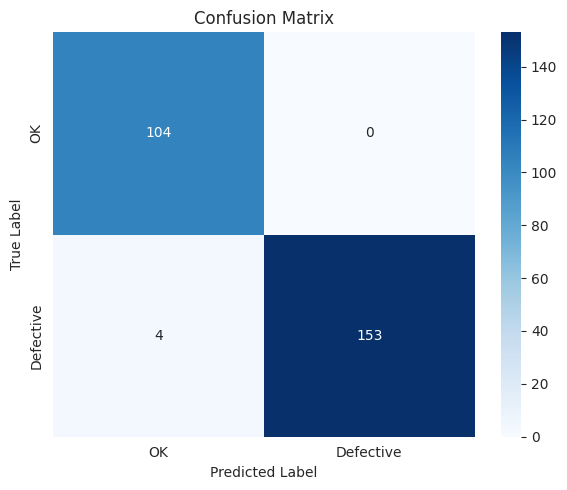

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["OK", "Defective"],
    yticklabels=["OK", "Defective"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

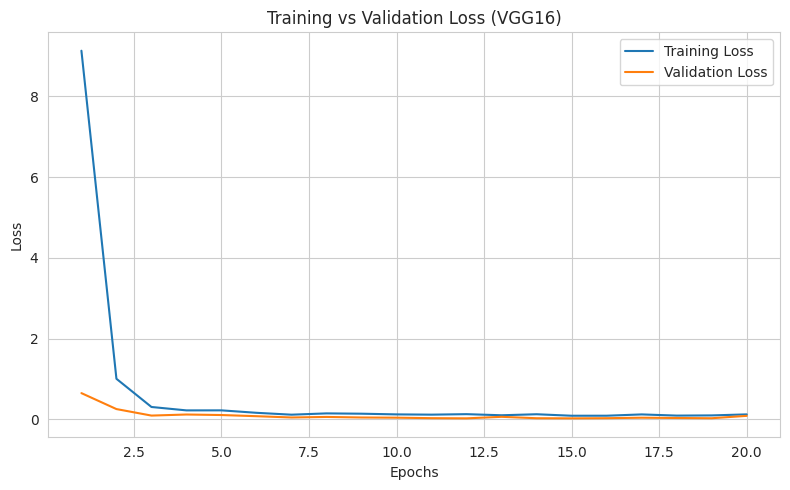

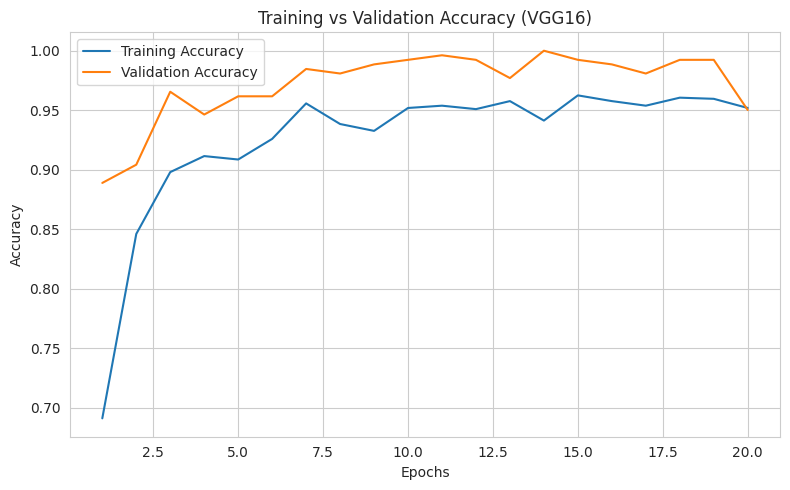

In [ ]:
import matplotlib.pyplot as plt

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.title("Training vs Validation Loss (VGG16)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")

plt.title("Training vs Validation Accuracy (VGG16)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
